In [61]:
folder_path = "../output/"

In [62]:
import os
import pandas as pd
df = pd.DataFrame(columns=[
    "model",
    "cwe",
    "iqr",
    "mean",
    "median",
    "min",
    "max",
    "perplexity"
])
for file in os.listdir(folder_path):
    if file.endswith(".jsonl") and file not in ["NVD-CWE-Other.jsonl"]:
        with open(folder_path + "/" + file, "r") as f:
            lines = f.readlines()
            import json
            for line in lines:
                data = json.loads(line)
                # {"cwe": "CWE-16", "model": "openai-community/gpt2", "vulnerable": [1717.9267578125], "safe": [372.79498291015625]}
                model = data["model"]
                cwe = data["cwe"]
                vulnerable = data["vulnerable"]
                safe = data["safe"]
                # compute the IQR
                import numpy as np
                vulnerable = np.array(vulnerable)
                safe = np.array(safe)
                iqr_vulnerable = np.percentile(vulnerable, 75) - np.percentile(vulnerable, 25)
                iqr_safe = np.percentile(safe, 75) - np.percentile(safe, 25)

                # compute the mean
                mean_vulnerable = np.mean(vulnerable)
                mean_safe = np.mean(safe)

                # compute the median
                median_vulnerable = np.median(vulnerable)
                median_safe = np.median(safe)

                # compute the min
                min_vulnerable = np.min(vulnerable)
                min_safe = np.min(safe)

                # compute the max
                max_vulnerable = np.max(vulnerable)
                max_safe = np.max(safe)

                # Store the results in a dataframe
                results_vulnerable = pd.DataFrame({
                    "model": [model],
                    "cwe": [cwe],
                    "iqr": [iqr_vulnerable],
                    "mean": [mean_vulnerable],
                    "median": [median_vulnerable],
                    "min": [min_vulnerable],
                    "max": [max_vulnerable],
                    "perplexity": [vulnerable]
                })
                results_safe = pd.DataFrame({
                    "model": [model],
                    "cwe": [cwe+" Patched"],
                    "iqr": [iqr_safe],
                    "mean": [mean_safe],
                    "median": [median_safe],
                    "min": [min_safe],
                    "max": [max_safe],
                    "perplexity": [safe]
                })
                
                df = pd.concat([df, results_vulnerable, results_safe], ignore_index=True)
                

    
                

/var/folders/b4/lwfgccm95kqd2skcwvrt2fr00000gn/T/ipykernel_16919/761664232.py:70: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, results_vulnerable, results_safe], ignore_index=True)


In [63]:
df["CWE_Number"] = df["cwe"].str.extract(r'(\d+)').astype(int)
df = df.sort_values(by=["CWE_Number", "model"])
#df = df.drop(columns=["CWE_Number"])
df

,model,cwe,iqr,mean,median,min,max,perplexity,CWE_Number
246,WizardLMTeam/WizardCoder-15B-V1.0,CWE-16,0.0,3.958694e+00,3.958694e+00,3.958694e+00,3.958694e+00,[3.9586942195892334],16
247,WizardLMTeam/WizardCoder-15B-V1.0,CWE-16 Patched,0.0,3.579939e+00,3.579939e+00,3.579939e+00,3.579939e+00,[3.579939365386963],16
248,exemplo,CWE-16,0.0,1.192676e+01,1.192676e+01,1.192676e+01,1.192676e+01,[11.9267578125],16
249,exemplo,CWE-16 Patched,0.0,2.279498e+01,2.279498e+01,2.279498e+01,2.279498e+01,[22.79498291015625],16
244,microsoft/codebert-base,CWE-16,0.0,2.088739e+07,2.088739e+07,2.088739e+07,2.088739e+07,[20887390.0],16
...,...,...,...,...,...,...,...,...,...
15,meta-llama/Llama-3.2-3B-Instruct,CWE-1021 Patched,0.0,8.104796e+00,8.104796e+00,8.104796e+00,8.104796e+00,[8.104796409606934],1021
16,microsoft/codebert-base,CWE-1021,0.0,1.059940e+07,1.059940e+07,1.059940e+07,1.059940e+07,[10599397.0],1021
17,microsoft/codebert-base,CWE-1021 Patched,0.0,1.127214e+07,1.127214e+07,1.127214e+07,1.127214e+07,[11272137.0],1021
12,openai-community/gpt2,CWE-1021,0.0,1.200020e+01,1.200020e+01,1.200020e+01,1.200020e+01,[12.000200271606445],1021


In [64]:
accpeted_models = [
    "openai-community/gpt2",
    #"microsoft/codebert-base",
    "WizardLMTeam/WizardCoder-15B-V1.0",
]

df = df[df["model"].isin(accpeted_models)]
df

,model,cwe,iqr,mean,median,min,max,perplexity,CWE_Number
246,WizardLMTeam/WizardCoder-15B-V1.0,CWE-16,0.000000,3.958694,3.958694,3.958694,3.958694,[3.9586942195892334],16
247,WizardLMTeam/WizardCoder-15B-V1.0,CWE-16 Patched,0.000000,3.579939,3.579939,3.579939,3.579939,[3.579939365386963],16
242,openai-community/gpt2,CWE-16,0.000000,1717.926758,1717.926758,1717.926758,1717.926758,[1717.9267578125],16
243,openai-community/gpt2,CWE-16 Patched,0.000000,372.794983,372.794983,372.794983,372.794983,[372.79498291015625],16
108,WizardLMTeam/WizardCoder-15B-V1.0,CWE-17,0.490051,2.266621,2.274170,1.651962,2.793242,"[2.437704086303711, 2.6137454509735107, 1.6519...",17
...,...,...,...,...,...,...,...,...,...
591,openai-community/gpt2,CWE-924 Patched,0.000000,8.924274,8.924274,8.924274,8.924274,[8.924274444580078],924
20,WizardLMTeam/WizardCoder-15B-V1.0,CWE-1021,0.000000,4.700834,4.700834,4.700834,4.700834,[4.700833797454834],1021
21,WizardLMTeam/WizardCoder-15B-V1.0,CWE-1021 Patched,0.000000,4.630003,4.630003,4.630003,4.630003,[4.630003452301025],1021
12,openai-community/gpt2,CWE-1021,0.000000,12.000200,12.000200,12.000200,12.000200,[12.000200271606445],1021


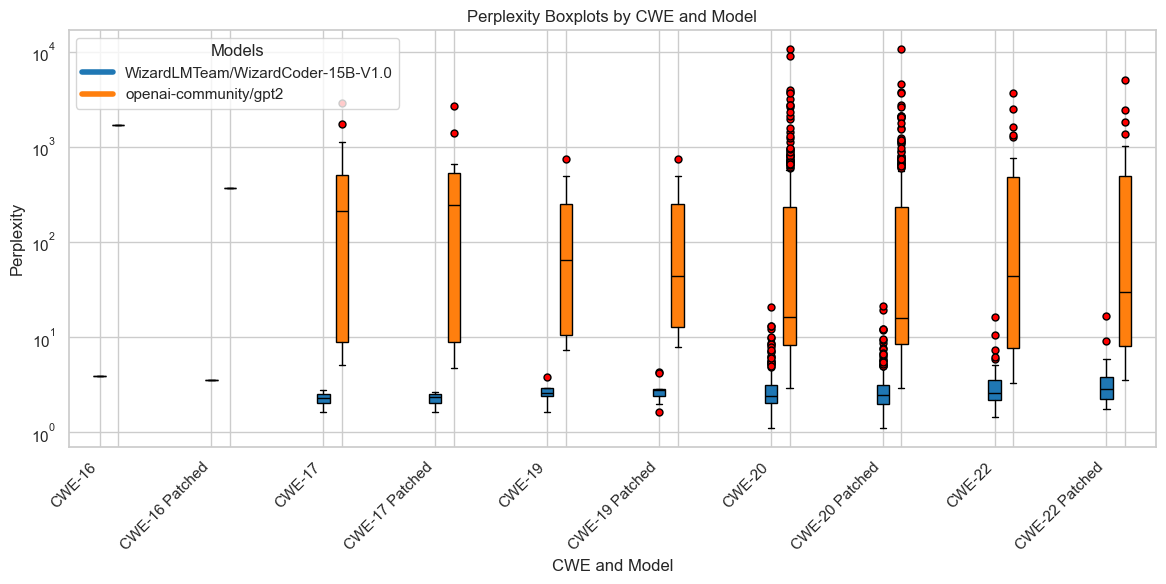

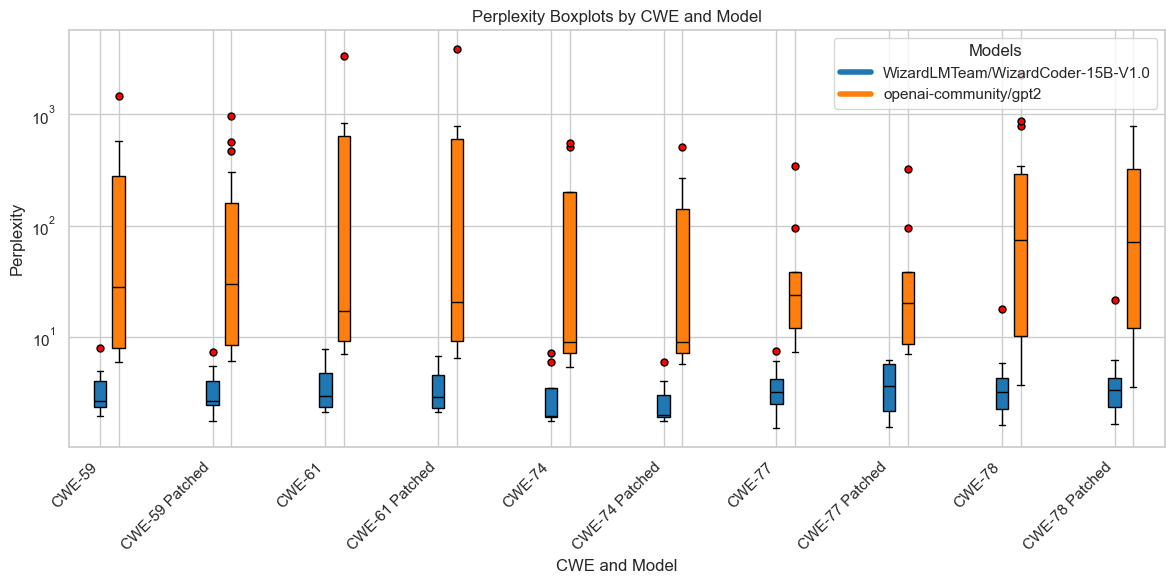

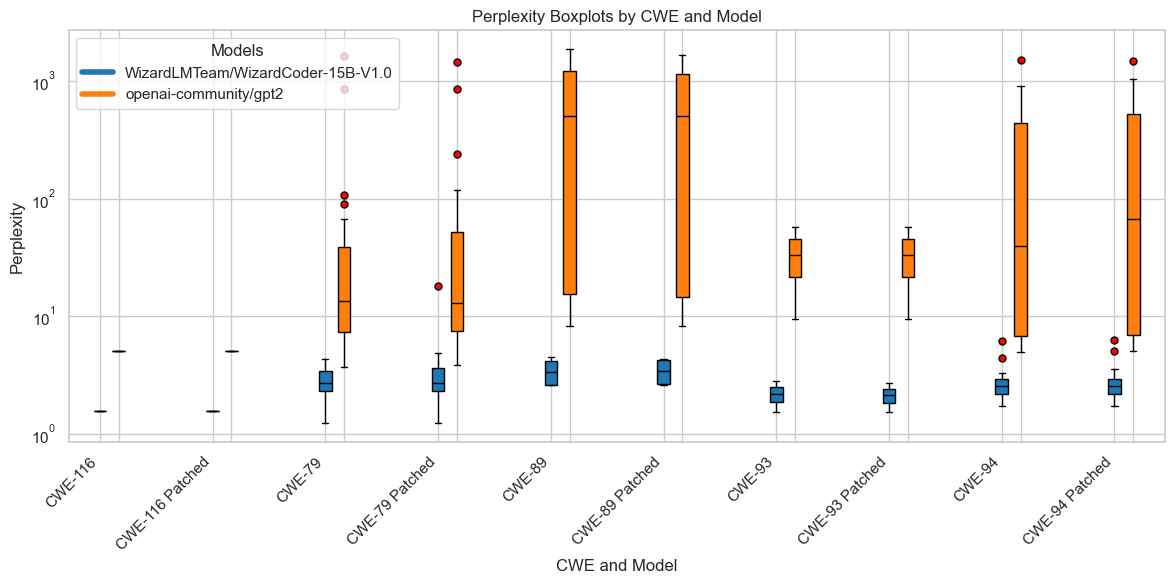

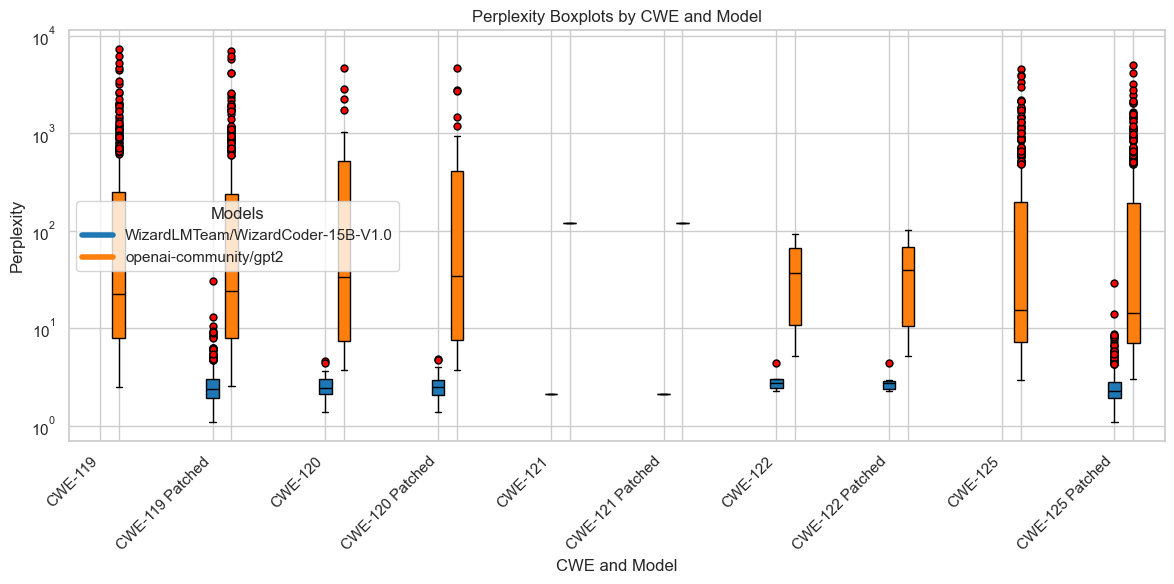

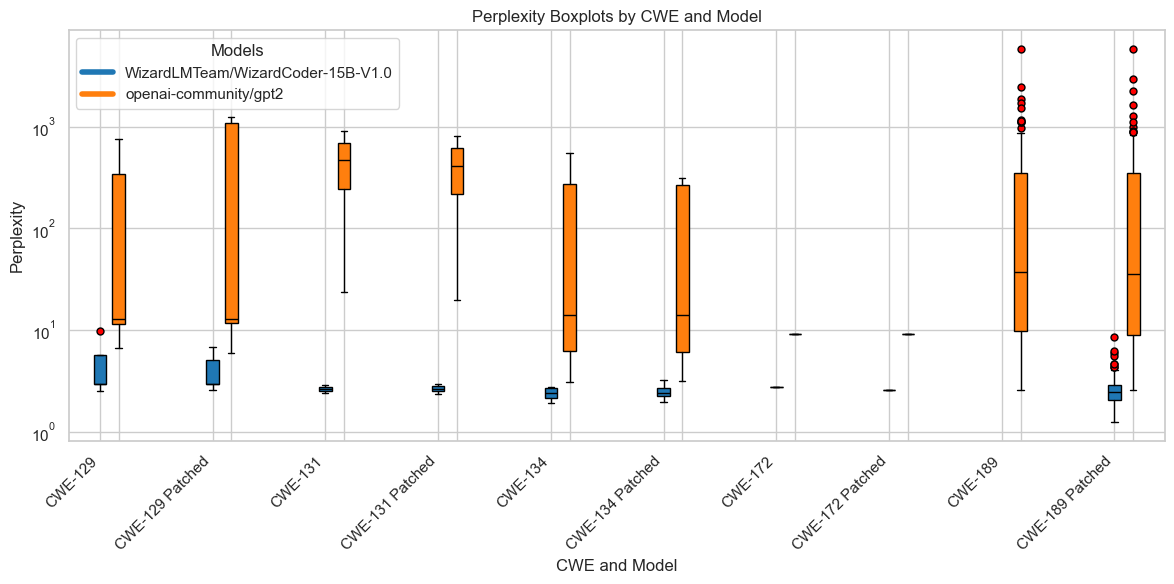

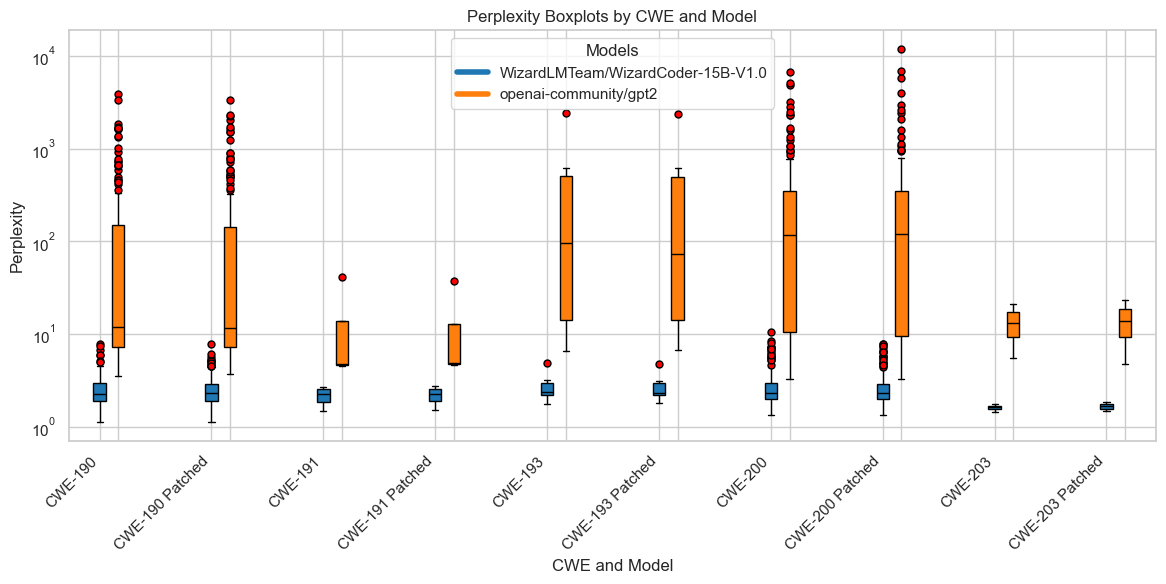

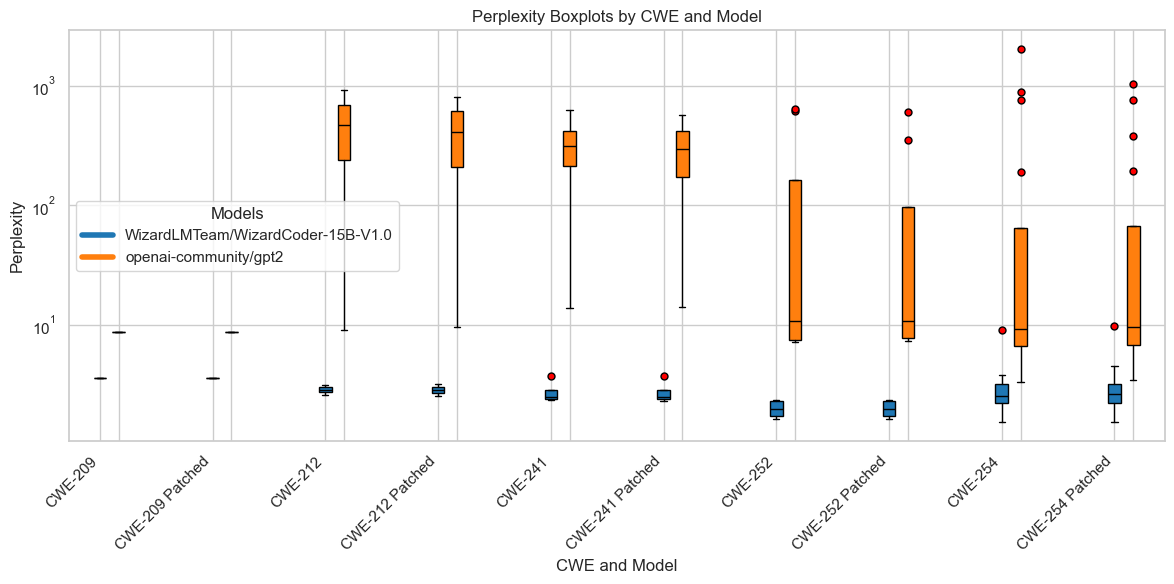

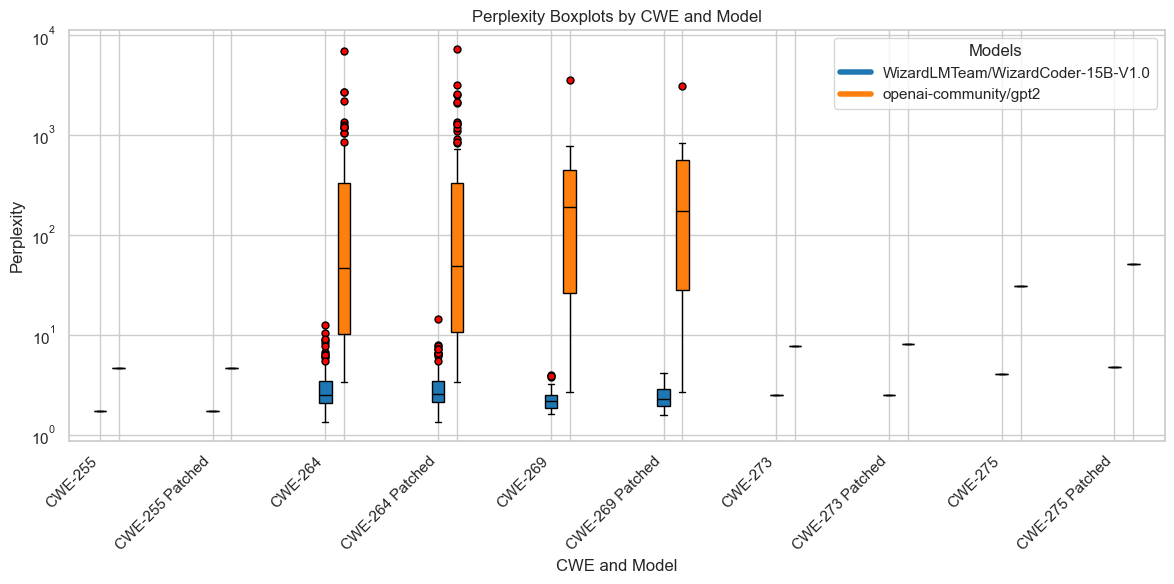

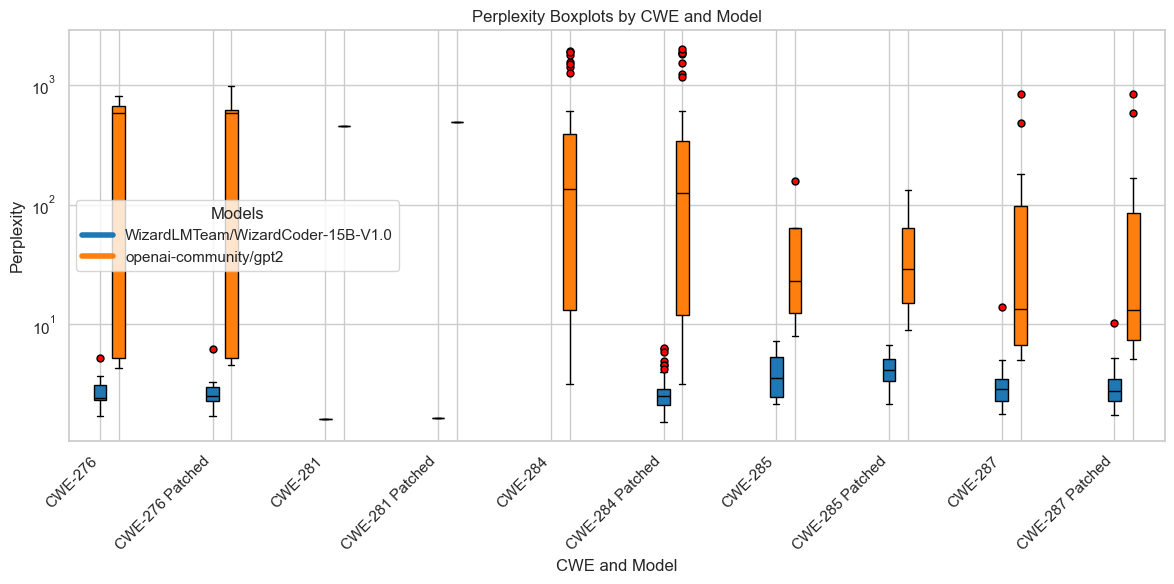

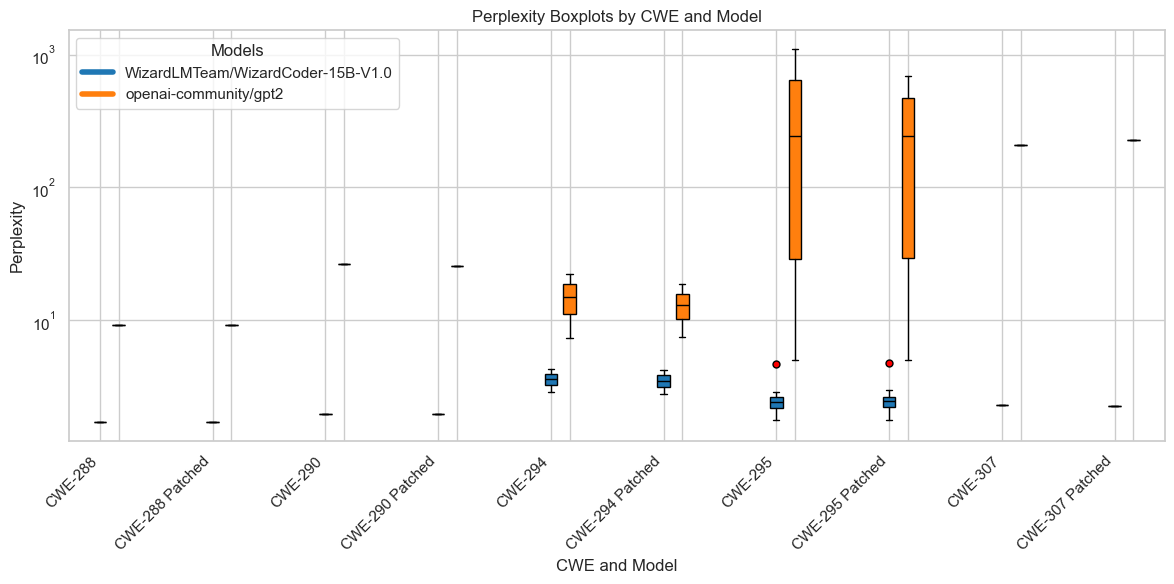

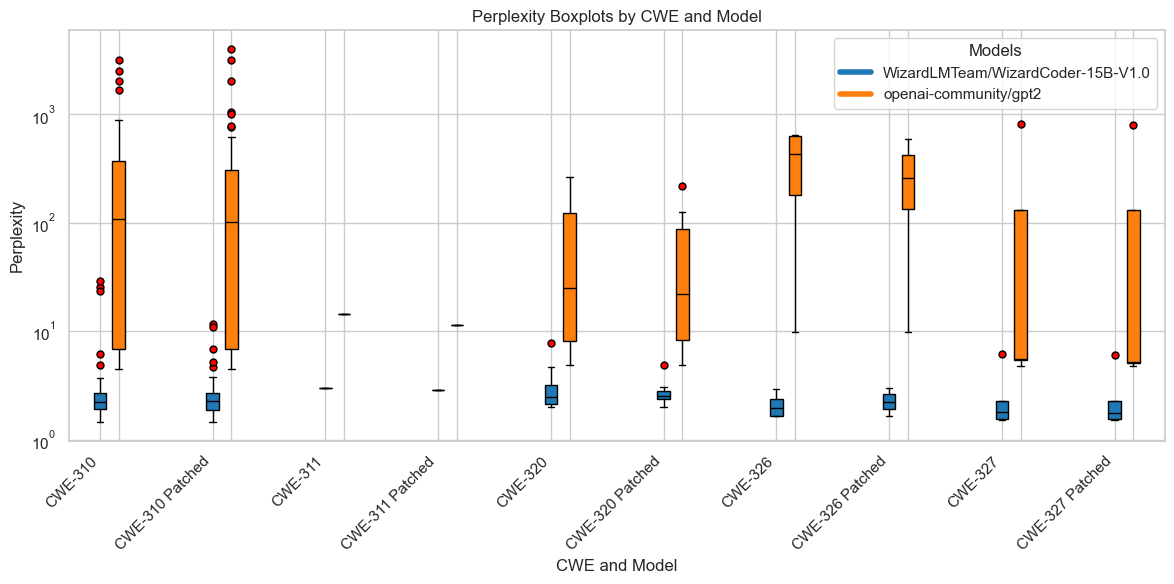

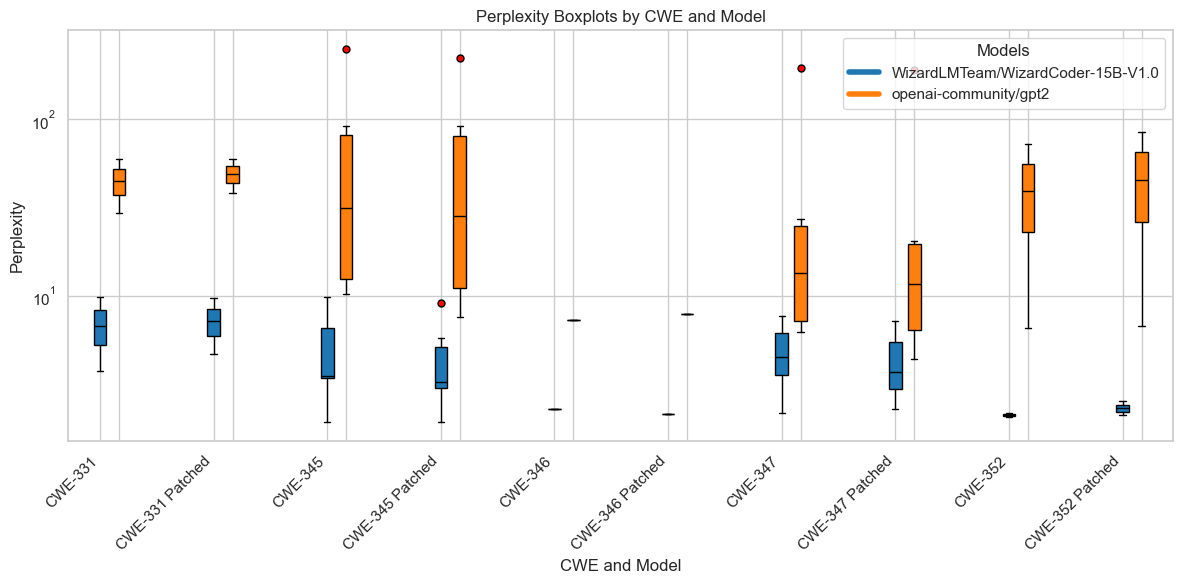

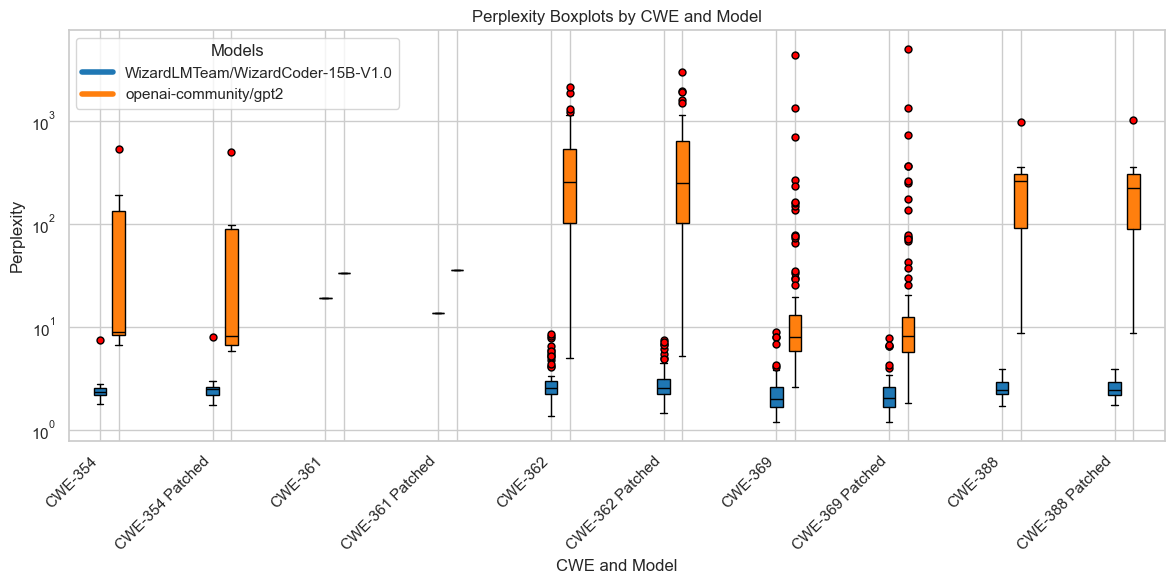

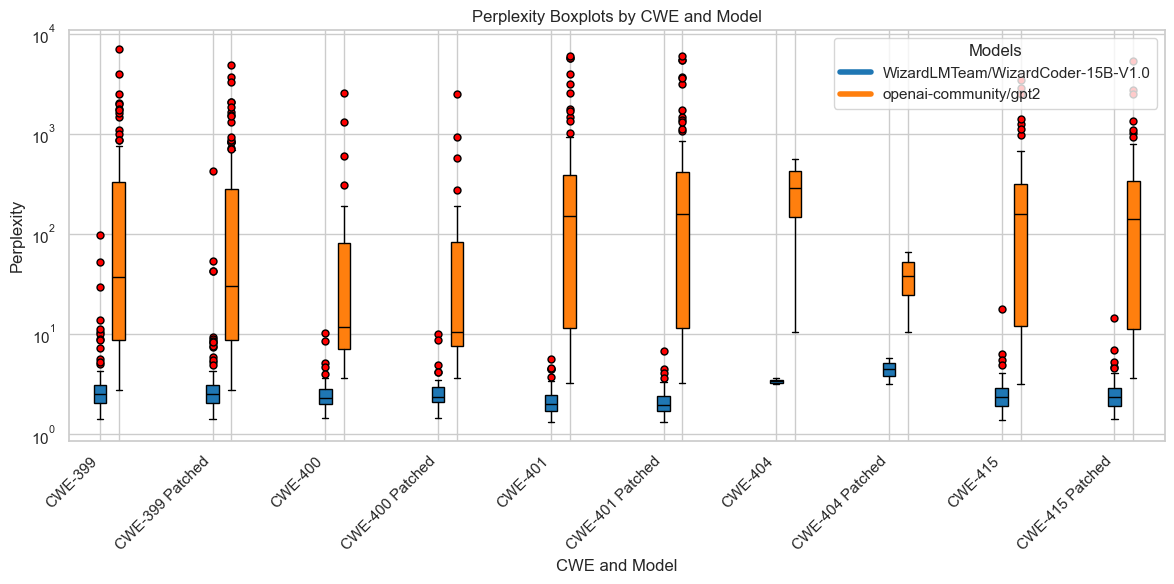

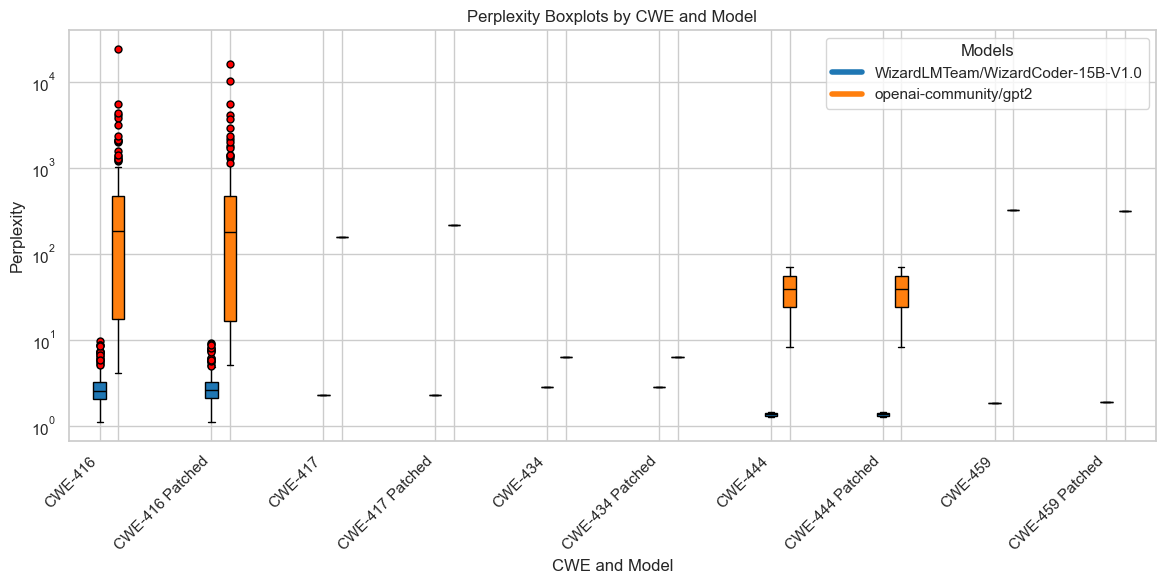

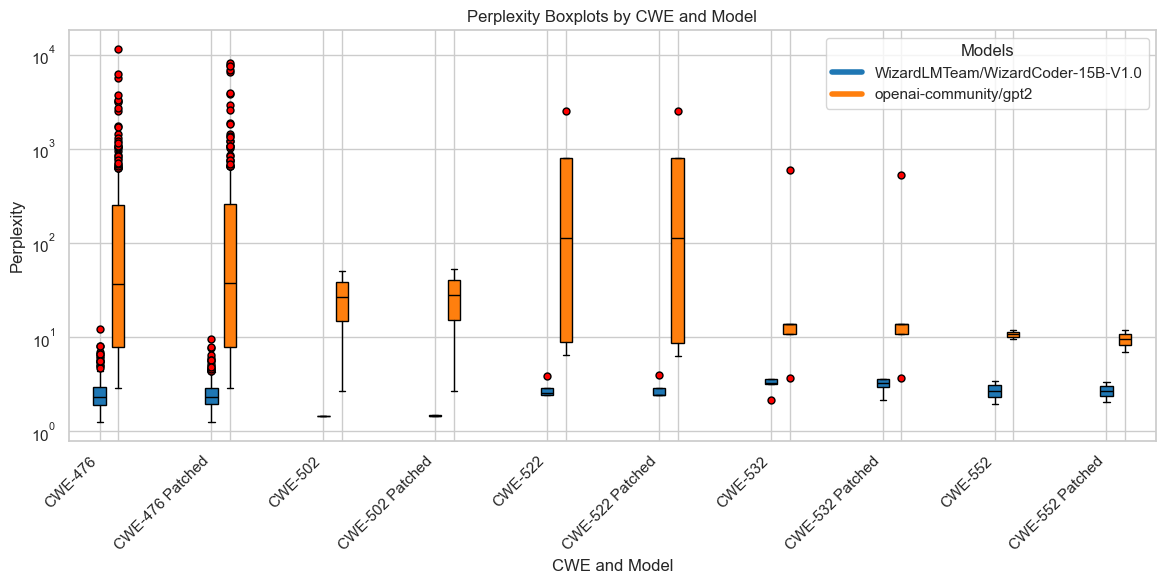

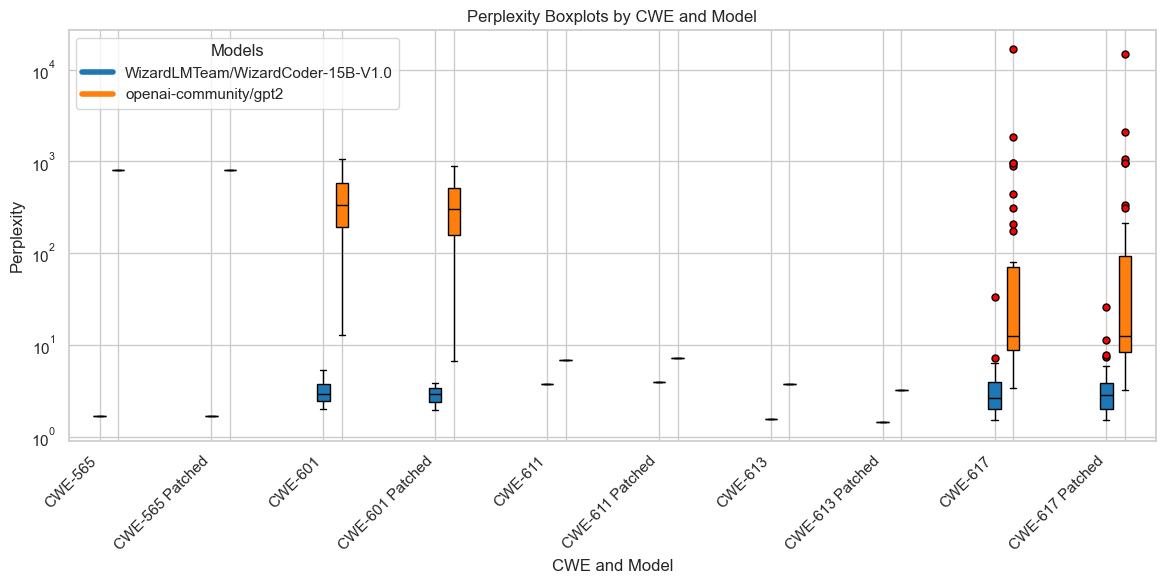

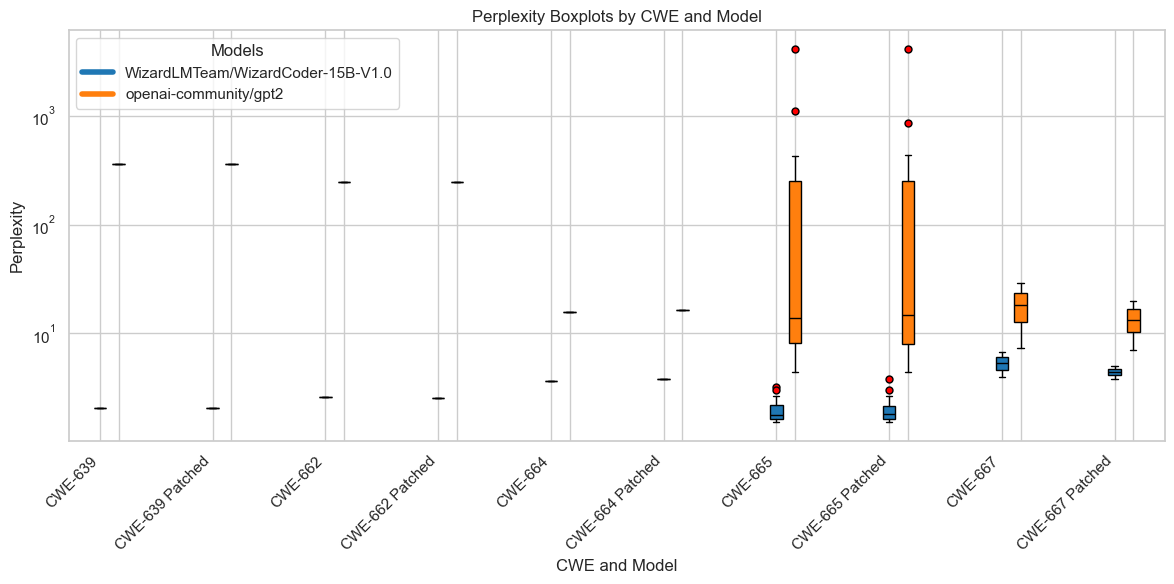

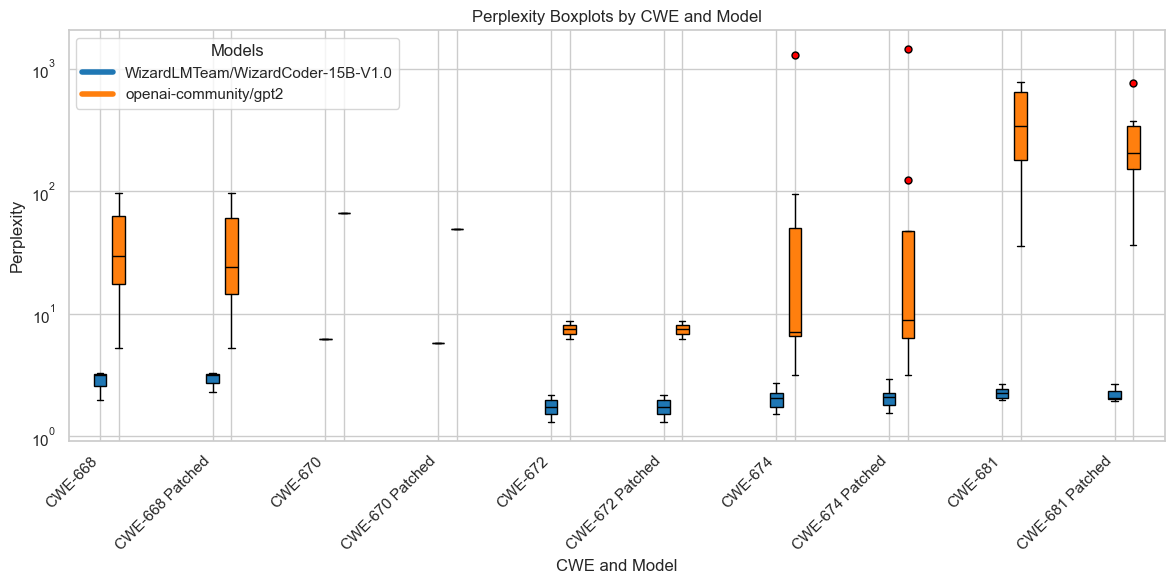

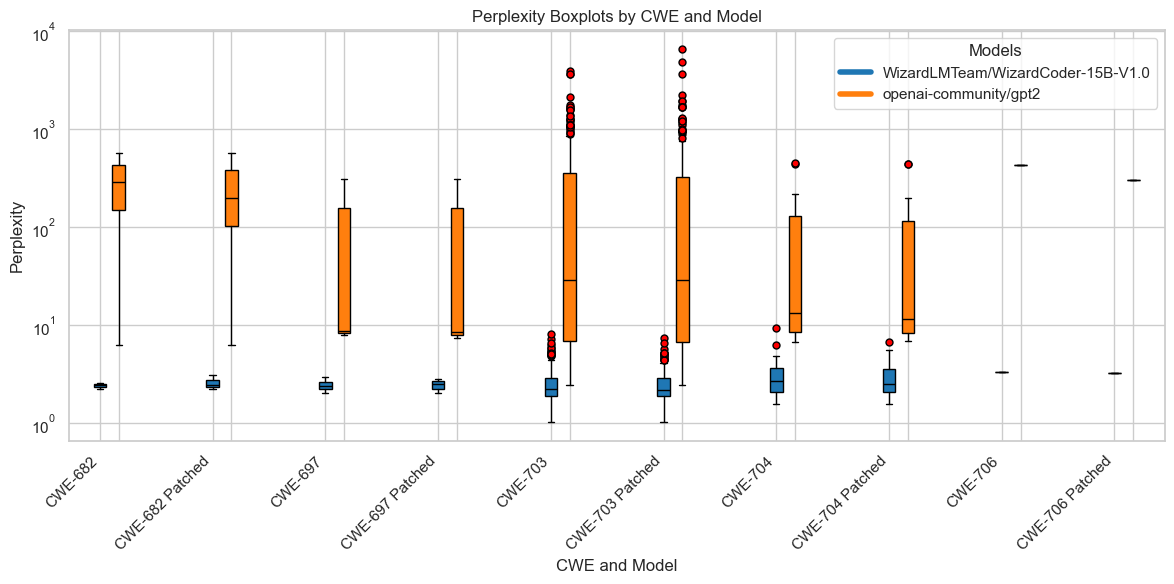

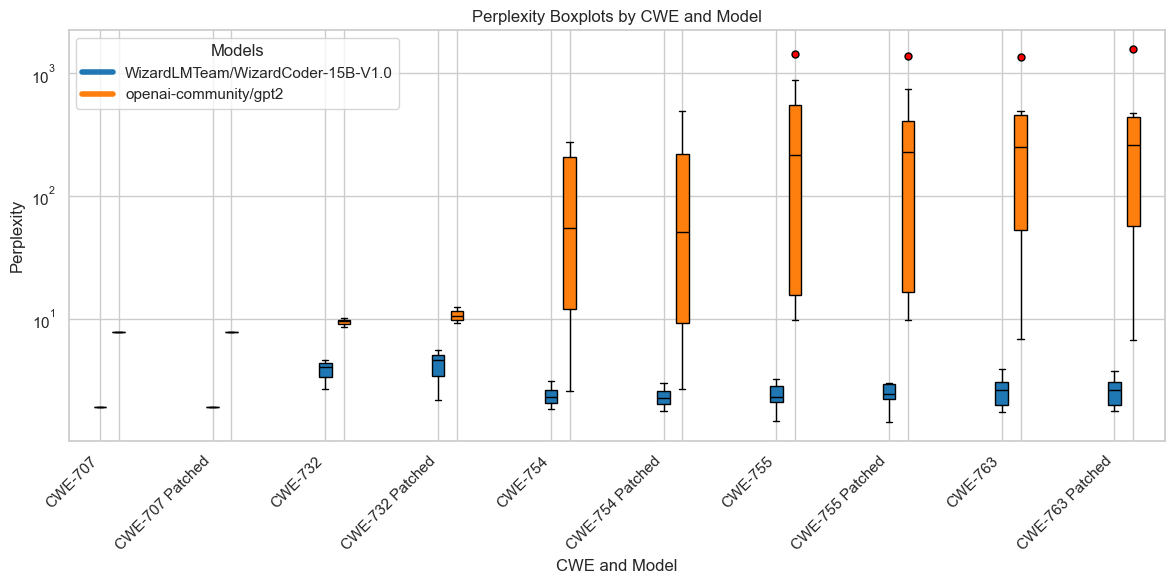

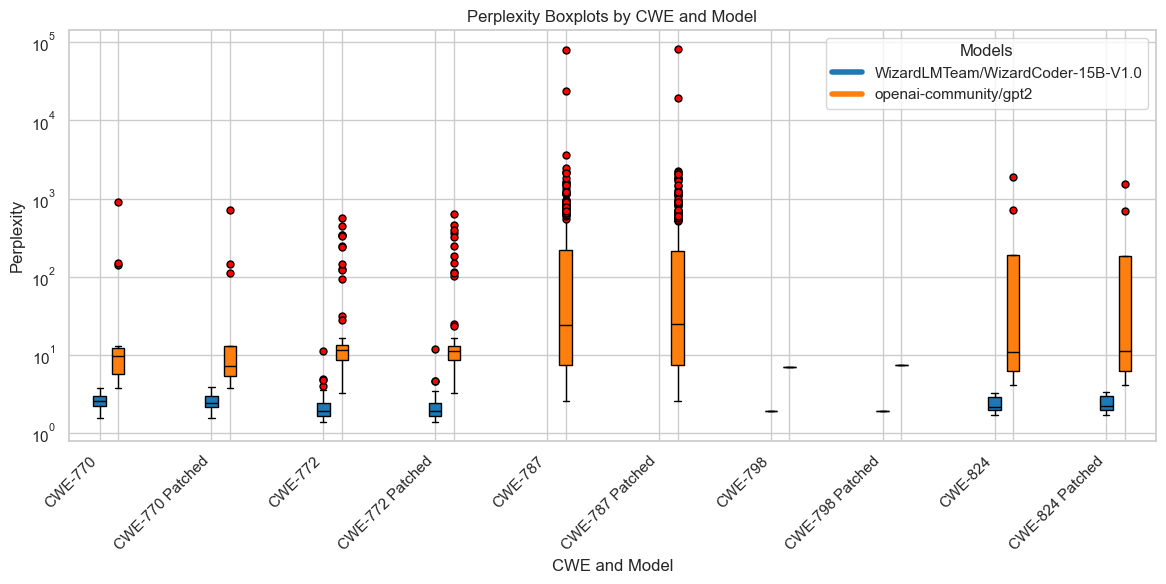

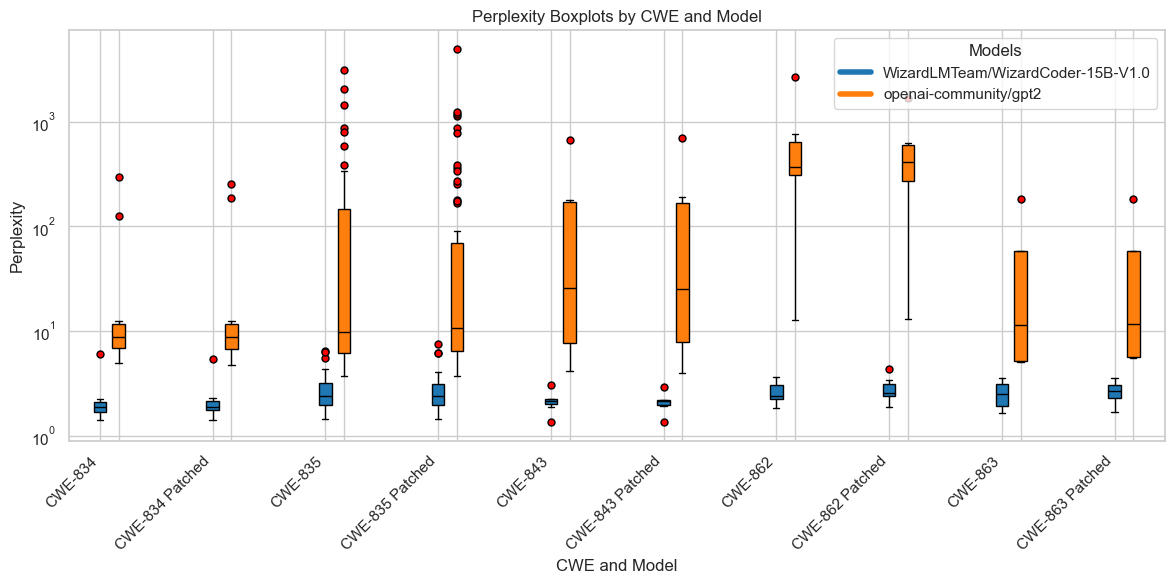

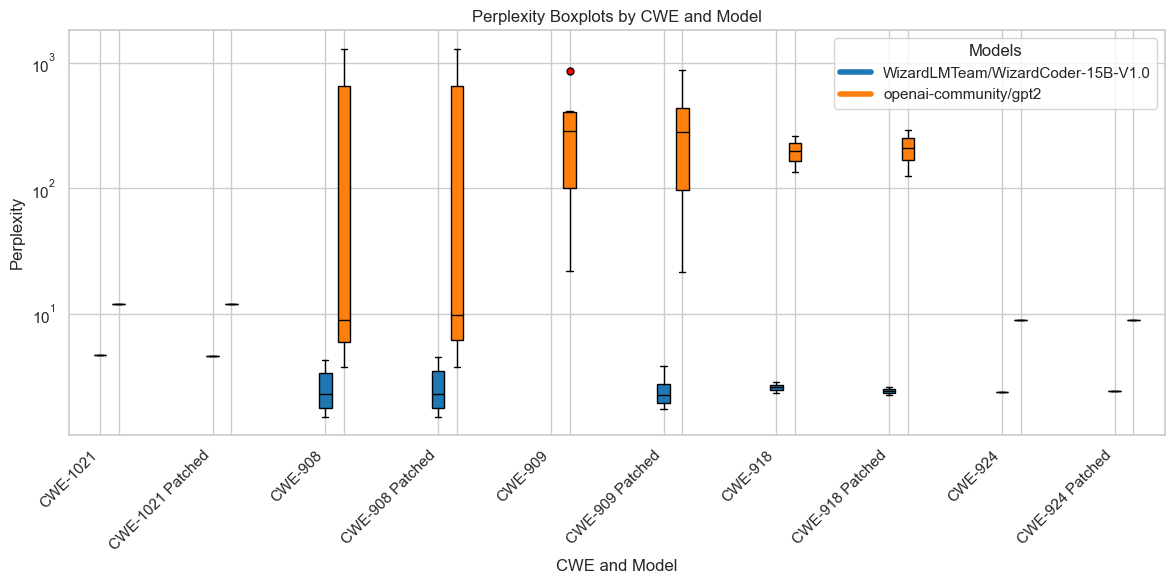

In [65]:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# # Sample DataFrame
# np.random.seed(42)
# data = {
#     "cwe": np.random.choice(["CWE-1", "CWE-2", "CWE-3", "CWE-4"], size=100),
#     "model": np.random.choice(["Model-A", "Model-B", "Model-C"], size=100),
#     "perplexity": np.random.rand(100) * 100
# }
# df = pd.DataFrame(data)


def plot_grouped_boxplots(df, cwe_subset, model_colors):
    plt.figure(figsize=(12, 6))
    
    # Filter data for selected CWEs
    subset_df = df[df["cwe"].isin(cwe_subset)]
    
    # Sort dataframe by CWE and model
    sorted_df = subset_df.sort_values(by=['cwe', 'model'])
    
    positions = []
    labels = []
    idx = 0
    cwe_spacing = 1.5  # Control spacing between different CWEs
    model_spacing = 0.3  # Control spacing between models under the same CWE

    legend_handles = {}  # To store legend handles
    
    # Grouping by CWE
    for cwe in sorted_df["cwe"].unique():
        cwe_df = sorted_df[sorted_df["cwe"] == cwe]
        cwe_base_idx = idx
        
        for j, model in enumerate(cwe_df["model"].unique()):
            model_df = cwe_df[cwe_df["model"] == model]
            pos = cwe_base_idx + j * model_spacing
            
            # Create boxplot and capture its elements
            box = plt.boxplot(
                model_df["perplexity"],
                positions=[pos],
                widths=0.2,
                patch_artist=True,
                medianprops=dict(color="black"),
                whiskerprops=dict(color="black"),
                capprops=dict(color="black"),
                flierprops=dict(marker="o", markersize=5, markerfacecolor="red"),
            )
            
            # Color the boxes appropriately
            for b in box['boxes']:
                b.set_facecolor(model_colors[model])

            # Store legend info
            if model not in legend_handles:
                legend_handles[model] = plt.Line2D([0], [0], color=model_colors[model], lw=4, label=model)

            if cwe not in labels:
                labels.append(cwe)
            else:
                labels.append("")
            positions.append(pos)
            
        # Update the index to keep CWEs close together
        idx = pos + cwe_spacing
    # Adjust x-axis labels
    plt.xticks(positions, labels, rotation=45, ha="right")
    plt.xlabel("CWE and Model")
    plt.ylabel("Perplexity")
    plt.title("Perplexity Boxplots by CWE and Model")
    plt.legend(handles=legend_handles.values(), title="Models")  # Add legend
    plt.tight_layout()
    plt.yscale("log")
    plt.show()

# Get unique CWE values
unique_cwes = df["cwe"].unique()

# Assign colors to models
unique_models = df['model'].unique()
model_colors = {model: plt.cm.tab10(i % 10) for i, model in enumerate(unique_models)}

# Define batch size
batch_size = 10

# Generate plots in batches
for i in range(0, len(unique_cwes), batch_size):
    cwe_batch = unique_cwes[i:i+batch_size]
    plot_grouped_boxplots(df, cwe_batch, model_colors)

In [66]:
cwe_tags = {
    "Injection Flaws": [
        "CWE-77", "CWE-78", "CWE-89", "CWE-94", "CWE-95", "CWE-116",
        "CWE-74", "CWE-79", "CWE-93"
    ],
    "Authentication Issues": [
        "CWE-287", "CWE-306", "CWE-798", "CWE-259",
        "CWE-255", "CWE-290", "CWE-307", "CWE-288", "CWE-294"
    ],
    "Authorization / Access Control": [
        "CWE-284", "CWE-285", "CWE-863", "CWE-732",
        "CWE-264", "CWE-275", "CWE-281", "CWE-639", "CWE-862"
    ],
    "Input Validation": [
        "CWE-20", "CWE-601", "CWE-134", "CWE-643",
        "CWE-129", "CWE-172", "CWE-682", "CWE-704", "CWE-707", "CWE-697"
    ],
    "File Handling": [
        "CWE-22", "CWE-73", "CWE-434", "CWE-97",
        "CWE-59", "CWE-61", "CWE-552"
    ],
    "Memory Management": [
        "CWE-119", "CWE-125", "CWE-787", "CWE-416",
        "CWE-120", "CWE-121", "CWE-122", "CWE-131", "CWE-401", "CWE-415", "CWE-417", "CWE-665", "CWE-667", "CWE-674", "CWE-763", "CWE-772"
    ],
    "Cryptography Issues": [
        "CWE-327", "CWE-328", "CWE-326", "CWE-311",
        "CWE-310", "CWE-320", "CWE-331"
    ],
    "Configuration": [
        "CWE-16", "CWE-250", "CWE-276", "CWE-269",
        "CWE-17", "CWE-19", "CWE-273", "CWE-924"
    ],
    "Error Handling / Logging": [
        "CWE-209", "CWE-248", "CWE-252",
        "CWE-388", "CWE-703", "CWE-704", "CWE-617", "CWE-532"
    ],
    "Information Disclosure": [
        "CWE-200", "CWE-201", "CWE-203",
        "CWE-212", "CWE-522", "CWE-613", "CWE-668", "CWE-918"
    ],
    "Denial of Service": [
        "CWE-400", "CWE-404", "CWE-770",
        "CWE-362", "CWE-369", "CWE-834", "CWE-835", "CWE-672"
    ],
    "Code Quality": [
        "CWE-561", "CWE-398", "CWE-563",
        "CWE-241", "CWE-254", "CWE-345", "CWE-346", "CWE-347", "CWE-354", "CWE-681", "CWE-682", "CWE-706", "CWE-754", "CWE-755"
    ],
    "Race Conditions / Concurrency": [
        "CWE-362", "CWE-361", "CWE-667", "CWE-663", "CWE-662"
    ],
    "Serialization / Deserialization": [
        "CWE-502"
    ],
    "XXE / XML Issues": [
        "CWE-611"
    ],
    "Security Misconfiguration": [
        "CWE-459", "CWE-565", "CWE-843", "CWE-909", "CWE-1021"
    ],
    "Unvalidated Redirects / CSRF": [
        "CWE-352"
    ],
    "Improper Certificate Validation": [
        "CWE-295", "CWE-346", "CWE-347"
    ],
    "Miscellaneous / Logic Issues": [
        "CWE-190", "CWE-191", "CWE-189", "CWE-193", "CWE-706", "CWE-664", "CWE-670", "CWE-843"
    ],
    "Object Injection / Insecure Deserialization": [
        "CWE-502"
    ],
    "Hardcoded Secrets / Weak Passwords": [
        "CWE-259", "CWE-798"
    ],
    "Improper Resource Access or Exposure": [
        "CWE-668", "CWE-552", "CWE-524", "CWE-918"
    ]
}


cwe_tags.setdefault("Authentication Issues", []).append("CWE-294")
cwe_tags.setdefault("Memory Management", []).extend(["CWE-399", "CWE-476", "CWE-824"])
cwe_tags.setdefault("Injection Flaws", []).append("CWE-444")
cwe_tags.setdefault("Resource Management", []).append("CWE-908")

In [72]:
df_cwe_tags = df.copy()
df_cwe_tags["cwe_tag"] = "Other"
# Assign CWE tags
for row in df_cwe_tags.itertuples():
    ends_with_patched = row.cwe.endswith(" Patched")
    row_cwe = row.cwe.split()[0] if row.cwe.endswith(" Patched") else row.cwe
    for tag, cwe_list in cwe_tags.items():
        if row_cwe in cwe_list:
            tag = tag if not ends_with_patched else tag + " Patched"
            df_cwe_tags.at[row.Index, "cwe_tag"] = tag 
            break


In [73]:
# group by cwe_tag and model
grouped_df = df_cwe_tags.groupby(["cwe_tag", "model"]).agg({
    "perplexity": lambda x: x.tolist()
}).reset_index()
grouped_df["perplexity"] = grouped_df["perplexity"].apply(lambda x: [item for sublist in x for item in sublist])

In [74]:
# Compute the IQR
grouped_df["iqr"] = grouped_df["perplexity"].apply(lambda x: np.percentile(x, 75) - np.percentile(x, 25))

# Compute the mean
grouped_df["mean"] = grouped_df["perplexity"].apply(lambda x: np.mean(x))

# Compute the median
grouped_df["median"] = grouped_df["perplexity"].apply(lambda x: np.median(x))

grouped_df

,cwe_tag,model,perplexity,iqr,mean,median
0,Authentication Issues,WizardLMTeam/WizardCoder-15B-V1.0,"[1.7427964210510254, 2.585188865661621, 2.6040...",1.260218,3.250975,2.594642
1,Authentication Issues,openai-community/gpt2,"[4.6851806640625, 8.82625961303711, 7.40564537...",59.127177,96.040626,11.252149
2,Authentication Issues Patched,WizardLMTeam/WizardCoder-15B-V1.0,"[1.732409119606018, 2.648861885070801, 2.60657...",1.249483,3.063932,2.627717
3,Authentication Issues Patched,openai-community/gpt2,"[4.636502265930176, 8.913769721984863, 8.71514...",49.780815,98.810046,11.217980
4,Authorization / Access Control,WizardLMTeam/WizardCoder-15B-V1.0,"[8.837165832519531, 2.3370213508605957, 3.6533...",NaN,NaN,NaN
...,...,...,...,...,...,...
75,Unvalidated Redirects / CSRF Patched,openai-community/gpt2,"[84.49688720703125, 6.74032735824585]",38.878280,45.618607,45.618607
76,XXE / XML Issues,WizardLMTeam/WizardCoder-15B-V1.0,[3.7759993076324463],0.000000,3.775999,3.775999
77,XXE / XML Issues,openai-community/gpt2,[6.780214786529541],0.000000,6.780215,6.780215
78,XXE / XML Issues Patched,WizardLMTeam/WizardCoder-15B-V1.0,[3.9401307106018066],0.000000,3.940131,3.940131


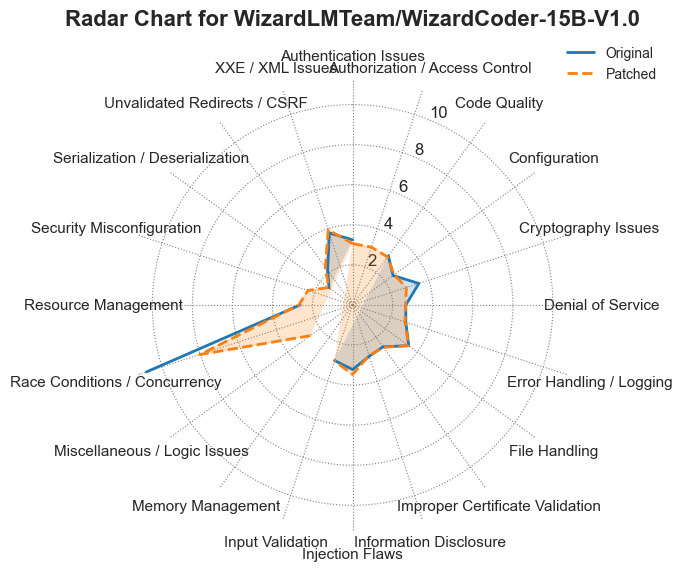

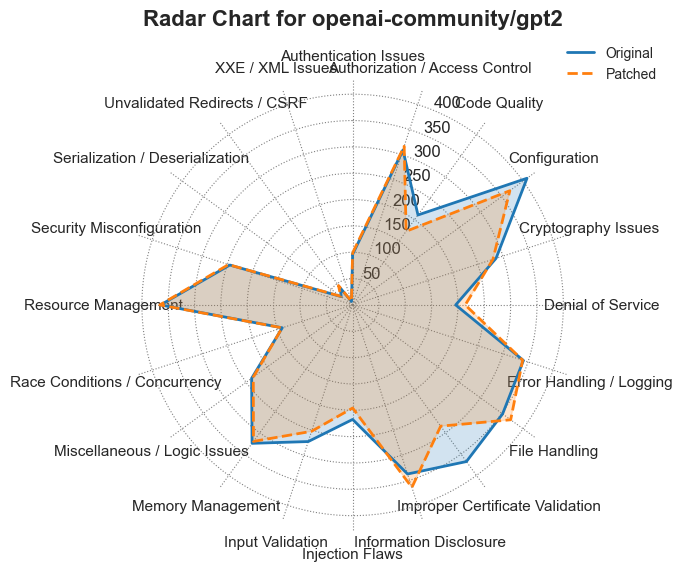

In [83]:
import matplotlib.pyplot as plt
import numpy as np

# Normalize CWE tags
grouped_df['base_cwe'] = grouped_df['cwe_tag'].str.replace(' Patched', '', regex=False)
grouped_df['patched'] = grouped_df['cwe_tag'].str.contains('Patched')

# Base tags and models
base_tags = grouped_df['base_cwe'].unique()
models = grouped_df['model'].unique()

# Radar chart setup
num_vars = len(base_tags)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

# Style settings
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 16,
    'legend.fontsize': 10,
})

# Color palette
colors = {#
    'Original': '#1f77b4',  # Blue
    'Patched': '#ff7f0e'    # Orange
}

# Create radar chart for each model
figures = []
for model in models:
    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    
    for is_patched, style in zip([False, True], ['solid', 'dashed']):
        label = 'Patched' if is_patched else 'Original'
        df_sub = grouped_df[(grouped_df['model'] == model) & (grouped_df['patched'] == is_patched)]
        values = df_sub.set_index('base_cwe').reindex(base_tags)['mean'].tolist()
        values += values[:1]
        
        ax.plot(angles, values, linestyle=style, linewidth=2, label=label, color=colors[label])
        ax.fill(angles, values, alpha=0.2, color=colors[label])
    
    # Aesthetics
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(base_tags, fontsize=11)
    ax.set_title(f'Radar Chart for {model}', y=1.1, fontweight='bold')
    ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1), frameon=False)
    ax.spines['polar'].set_visible(False)
    ax.grid(color='gray', linestyle='dotted', linewidth=0.8)
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    plt.tight_layout()
    
    figures.append(fig)

plt.show()
